In [474]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.circuit.library import RealAmplitudes, ZZFeatureMap
from qiskit_algorithms.optimizers import COBYLA, L_BFGS_B,GradientDescent,SPSA,BOBYQA
from qiskit_algorithms.utils import algorithm_globals

from qiskit_machine_learning.algorithms.classifiers import NeuralNetworkClassifier, VQC
from qiskit_machine_learning.algorithms.regressors import NeuralNetworkRegressor, VQR
from qiskit_machine_learning.neural_networks import SamplerQNN, EstimatorQNN
from qiskit_machine_learning.circuit.library import QNNCircuit

In [475]:
# Load CSV and columns
df = pd.read_csv("C:/Users/IITIEE/Desktop/SOUMEN DAS/Data_set/Housing (1).csv")
print(df)

     rownames   price  lotsize  bedrooms  bathrms  stories driveway recroom fullbase gashw airco  garagepl prefarea
0           1   42000     5850         3        1        2      yes      no      yes    no    no         1       no
1           2   38500     4000         2        1        1      yes      no       no    no    no         0       no
2           3   49500     3060         3        1        1      yes      no       no    no    no         0       no
3           4   60500     6650         3        1        2      yes     yes       no    no    no         0       no
4           5   61000     6360         2        1        1      yes      no       no    no    no         0       no
..        ...     ...      ...       ...      ...      ...      ...     ...      ...   ...   ...       ...      ...
541       542   91500     4800         3        2        4      yes     yes       no    no   yes         0       no
542       543   94000     6000         3        2        4      yes     

In [476]:
Y = df['price']   #dependent or target variable
X = df['lotsize']  # independent or feature variable

In [477]:
print(type(X))
print(X.shape)
print(type(Y))
print(Y.shape)

<class 'pandas.core.series.Series'>
(546,)
<class 'pandas.core.series.Series'>
(546,)


In [478]:
X=X.values.reshape(len(X),1)
print(X.shape)
Y=Y.values.reshape(len(Y),1)
print(Y.shape)

(546, 1)
(546, 1)


In [479]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

X= scaler.fit_transform(X)
print("lotsize =\n",X)



lotsize =
 [[0.28865979]
 [0.16151203]
 [0.09690722]
 [0.34364261]
 [0.32371134]
 [0.17250859]
 [0.1532646 ]
 [0.17250859]
 [0.21649485]
 [0.26460481]
 [0.3814433 ]
 [0.09278351]
 [0.00343643]
 [0.08453608]
 [0.13402062]
 [0.10549828]
 [0.11340206]
 [0.24398625]
 [0.12371134]
 [0.16054983]
 [0.21546392]
 [0.19656357]
 [0.16151203]
 [0.15697595]
 [0.22749141]
 [0.09278351]
 [0.14776632]
 [0.22749141]
 [0.09278351]
 [0.19587629]
 [0.12714777]
 [0.12714777]
 [0.16151203]
 [0.19587629]
 [0.32371134]
 [0.19587629]
 [0.16371134]
 [0.2419244 ]
 [0.25773196]
 [0.10309278]
 [0.14398625]
 [0.19725086]
 [0.20549828]
 [0.47628866]
 [0.02405498]
 [0.03505155]
 [0.09553265]
 [0.09896907]
 [0.22749141]
 [0.11683849]
 [0.25085911]
 [0.16838488]
 [0.51656357]
 [0.16426117]
 [0.13608247]
 [0.13539519]
 [0.05154639]
 [0.38556701]
 [0.18900344]
 [0.05154639]
 [0.16975945]
 [0.21305842]
 [0.18075601]
 [0.21786942]
 [0.26460481]
 [0.26460481]
 [0.23298969]
 [0.29896907]
 [0.05841924]
 [0.16804124]
 [0.16804

In [480]:
Y= scaler.fit_transform(Y)
print("\n price =\n",Y)


 price =
 [[0.1030303 ]
 [0.08181818]
 [0.14848485]
 [0.21515152]
 [0.21818182]
 [0.24848485]
 [0.24848485]
 [0.26666667]
 [0.35636364]
 [0.38484848]
 [0.39393939]
 [0.03333333]
 [0.01212121]
 [0.06666667]
 [0.07272727]
 [0.07818182]
 [0.09393939]
 [0.09545455]
 [0.12121212]
 [0.12121212]
 [0.14242424]
 [0.24787879]
 [0.07818182]
 [0.07878788]
 [0.1030303 ]
 [0.10484848]
 [0.11212121]
 [0.11515152]
 [0.11818182]
 [0.12060606]
 [0.12121212]
 [0.13939394]
 [0.14545455]
 [0.16060606]
 [0.21818182]
 [0.21818182]
 [0.22242424]
 [0.25454545]
 [0.34545455]
 [0.17878788]
 [0.25151515]
 [0.27272727]
 [0.34545455]
 [0.40606061]
 [0.07878788]
 [0.11515152]
 [0.0969697 ]
 [0.10909091]
 [0.13939394]
 [0.18060606]
 [0.18181818]
 [0.19393939]
 [0.26060606]
 [0.42424242]
 [0.07878788]
 [0.        ]
 [0.00148485]
 [0.18787879]
 [0.06363636]
 [0.03030303]
 [0.13939394]
 [0.13939394]
 [0.16363636]
 [0.17575758]
 [0.18787879]
 [0.21212121]
 [0.21212121]
 [0.25454545]
 [0.13333333]
 [0.27272727]
 [0.12121

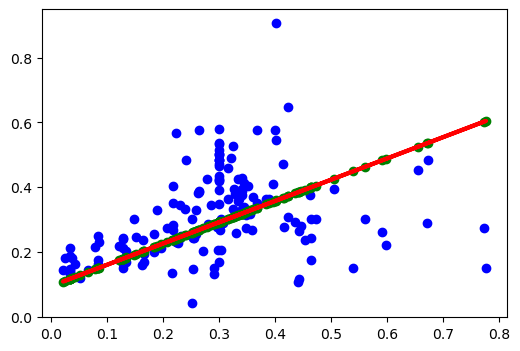

regression score= 1.0


In [481]:
# Split the data into training/testing sets
X_train = X[:-150]
X_test = X[-150:]
  
# Split the targets into training/testing sets
Y_train = Y[:-150]
Y_test = Y[-150:]
  
# Create a linear regression object
regr = linear_model.LinearRegression()

# Train the model using the training sets
regr.fit(X_train, Y_train)
y_pred=regr.predict(X_test)

#plot 
plt.plot(X_test, Y_test, "bo")
plt.plot(X_test, y_pred, "go")
plt.plot(X_test,y_pred , color='Red',linewidth=3)
plt.show()
reg_score=regr.score(X_test, y_pred)
print("regression score=",reg_score)

In [482]:
X_new_lots_size=[0.3443299,0.12852234,0.25085911,0.24085311,0.3814433,0.21649485,0.14226804] # unknown/new data for validation testing
X_new_lots_size= np.asarray(X_new_lots_size)
X_new_lots_size=X_new_lots_size.reshape(len(X_new_lots_size), 1)

#prediction of price over new data
predicted_price=regr.predict(X_new_lots_size)
print(predicted_price)
#print(predicted_price)
for i in range(0,len(X_new_lots_size)):
    for j in range(i,len(predicted_price)):
        print("predicted price of lot_size ",X_new_lots_size[i],"is=",predicted_price[j])
        break

[[0.3212686 ]
 [0.17974531]
 [0.25997189]
 [0.25341011]
 [0.345607  ]
 [0.23743633]
 [0.18875953]]
predicted price of lot_size  [0.3443299] is= [0.3212686]
predicted price of lot_size  [0.12852234] is= [0.17974531]
predicted price of lot_size  [0.25085911] is= [0.25997189]
predicted price of lot_size  [0.24085311] is= [0.25341011]
predicted price of lot_size  [0.3814433] is= [0.345607]
predicted price of lot_size  [0.21649485] is= [0.23743633]
predicted price of lot_size  [0.14226804] is= [0.18875953]


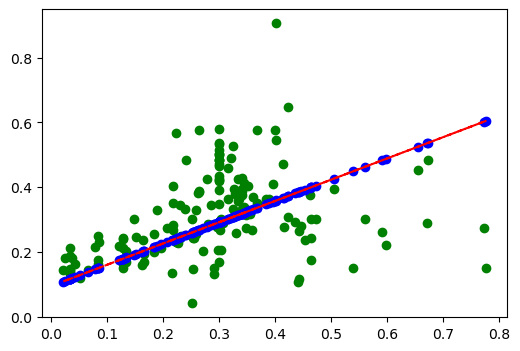

In [483]:
# plot target function
plt.plot(X_test,Y_test, "go")
#plt.plot(X_test, Y_test, "g--")
# plot data
plt.plot(X_test, y_pred, "bo")

# plot fitted line
plt.plot(X_test, y_pred, "r--")
plt.show()

In [484]:
# construct simple feature map
param_x = Parameter("x")
feature_map = QuantumCircuit(1, name="fm")
feature_map.ry(param_x, 0)
print(feature_map)
print(feature_map.ry(param_x, 0))
# construct simple ansatz
param_y = Parameter("y")
ansatz = QuantumCircuit(1, name="vf")
ansatz.ry(param_y, 0)
print(ansatz)
print(ansatz.ry(param_y, 0))
# construct a circuit
qc = QNNCircuit(feature_map=feature_map, ansatz=ansatz)

# construct QNN
regression_estimator_qnn = EstimatorQNN(circuit=qc)

   ┌───────┐
q: ┤ Ry(x) ├
   └───────┘
   ┌───────┐
q: ┤ Ry(y) ├
   └───────┘


In [485]:
def callback_graph(weights, obj_func_eval):
    clear_output(wait=True)
    objective_func_vals.append(obj_func_eval)
    plt.title("Objective function value against iteration")
    plt.xlabel("Iteration")
    plt.ylabel("Objective function value")
    plt.plot(range(len(objective_func_vals)), objective_func_vals)
    plt.show()

In [486]:
num_iter=int(input("How many times you want to iterate ="))

How many times you want to iterate = 200


In [487]:
# construct the regressor from the neural network
regressor = NeuralNetworkRegressor(
    neural_network=regression_estimator_qnn,
    loss="squared_error",
    optimizer=SPSA(maxiter=num_iter),
    callback=callback_graph,
  
)
print(regressor.callback)


<function callback_graph at 0x000002415B40DE40>


In [488]:
print(X_train)
print(len(X_train))
print(Y_train)
print(len(Y_train))

[[0.28865979]
 [0.16151203]
 [0.09690722]
 [0.34364261]
 [0.32371134]
 [0.17250859]
 [0.1532646 ]
 [0.17250859]
 [0.21649485]
 [0.26460481]
 [0.3814433 ]
 [0.09278351]
 [0.00343643]
 [0.08453608]
 [0.13402062]
 [0.10549828]
 [0.11340206]
 [0.24398625]
 [0.12371134]
 [0.16054983]
 [0.21546392]
 [0.19656357]
 [0.16151203]
 [0.15697595]
 [0.22749141]
 [0.09278351]
 [0.14776632]
 [0.22749141]
 [0.09278351]
 [0.19587629]
 [0.12714777]
 [0.12714777]
 [0.16151203]
 [0.19587629]
 [0.32371134]
 [0.19587629]
 [0.16371134]
 [0.2419244 ]
 [0.25773196]
 [0.10309278]
 [0.14398625]
 [0.19725086]
 [0.20549828]
 [0.47628866]
 [0.02405498]
 [0.03505155]
 [0.09553265]
 [0.09896907]
 [0.22749141]
 [0.11683849]
 [0.25085911]
 [0.16838488]
 [0.51656357]
 [0.16426117]
 [0.13608247]
 [0.13539519]
 [0.05154639]
 [0.38556701]
 [0.18900344]
 [0.05154639]
 [0.16975945]
 [0.21305842]
 [0.18075601]
 [0.21786942]
 [0.26460481]
 [0.26460481]
 [0.23298969]
 [0.29896907]
 [0.05841924]
 [0.16804124]
 [0.16804124]
 [0.10

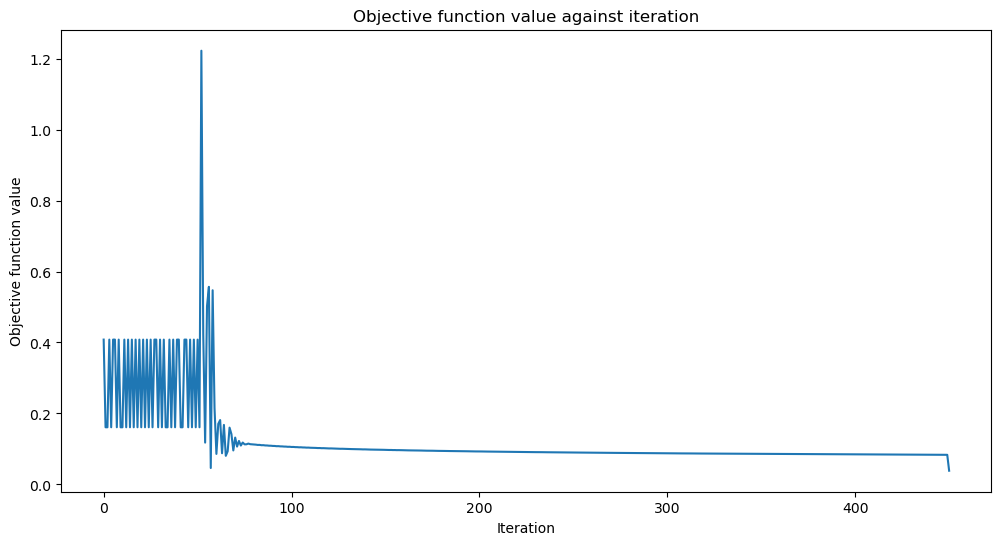

Training time: 1183 seconds
regressor_score= -0.6874313722723879


In [489]:
import time
# create empty array for the callback to store evaluations of the objective function
objective_func_vals = []
plt.rcParams["figure.figsize"] = (12, 6)

start = time.time()
regressor.fit(X_train, Y_train)# fit to data
elapsed = time.time() - start
print(f"Training time: {round(elapsed)} seconds")

# return to default figsize
plt.rcParams["figure.figsize"] = (6, 4)

# score the result
regressor_score=regressor.score(X, Y)
print("regressor_score=",regressor_score)

In [490]:
#X_new_lots_size=[0.3443299,0.12852234,0.25085911,0.24085311] # unknown/new data for validation testing

X_new_lots_size= np.asarray(X_new_lots_size)
X_new_lots_size=X_new_lots_size.reshape(len(X_new_lots_size), 1)
print(X_new_lots_size)
print(type(X_new_lots_size))
#prediction of price over new data
predicted_price_QML=regressor.predict(X_new_lots_size)

for i in range(0,len(X_new_lots_size)):
    for j in range(i,len(predicted_price_QML)):
        print("predicted price of lot_size ",X_new_lots_size[i],"is=",predicted_price_QML[j])
        break

[[0.3443299 ]
 [0.12852234]
 [0.25085911]
 [0.24085311]
 [0.3814433 ]
 [0.21649485]
 [0.14226804]]
<class 'numpy.ndarray'>
predicted price of lot_size  [0.3443299] is= [0.50783495]
predicted price of lot_size  [0.12852234] is= [0.10088265]
predicted price of lot_size  [0.25085911] is= [0.33888178]
predicted price of lot_size  [0.24085311] is= [0.31998731]
predicted price of lot_size  [0.3814433] is= [0.57032091]
predicted price of lot_size  [0.21649485] is= [0.27347083]
predicted price of lot_size  [0.14226804] is= [0.12819223]


In [491]:
print(X_new_lots_size,"\n")
print(predicted_price,"\n")
print(predicted_price_QML)

[[0.3443299 ]
 [0.12852234]
 [0.25085911]
 [0.24085311]
 [0.3814433 ]
 [0.21649485]
 [0.14226804]] 

[[0.3212686 ]
 [0.17974531]
 [0.25997189]
 [0.25341011]
 [0.345607  ]
 [0.23743633]
 [0.18875953]] 

[[0.50783495]
 [0.10088265]
 [0.33888178]
 [0.31998731]
 [0.57032091]
 [0.27347083]
 [0.12819223]]


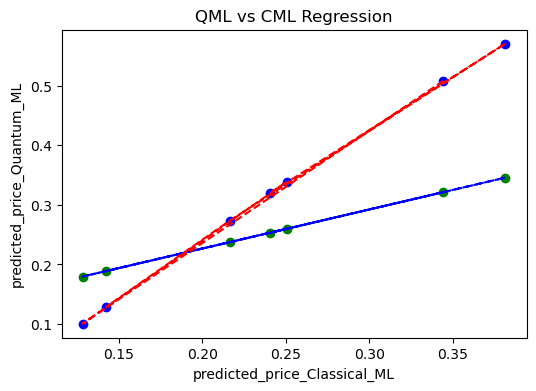

In [492]:
# plot target function
plt.plot(X_new_lots_size,predicted_price, "go")
plt.plot(X_new_lots_size, predicted_price, "b--")# plot fitted line

# plot data
plt.plot(X_new_lots_size,predicted_price_QML, "bo")
plt.plot(X_new_lots_size, predicted_price_QML, "r--")# plot fitted line

plt.title("QML vs CML Regression")
plt.xlabel("predicted_price_Classical_ML")
plt.ylabel("predicted_price_Quantum_ML")
plt.show()